In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

### 1. Dataset sintetis sederhana

In [ ]:
np.random.seed(42)
n_samples = 1000
n_features = 2
X_train = np.random.randn(n_samples, n_features)
y_train = (X_train[:, 0] + X_train[:, 1] > 0).astype(np.int32)
X_test = np.random.randn(200, n_features)
y_test = (X_test[:, 0] + X_test[:, 1] > 0).astype(np.int32)

### 2. Buat model sederhana

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(16, activation='relu', input_shape=(n_features,)),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### 3. Train model

In [ ]:
model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=1)

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5149 - loss: 0.6895
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8424 - loss: 0.6105 
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9117 - loss: 0.5496
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9495 - loss: 0.4987
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9648 - loss: 0.4424 
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9702 - loss: 0.3889
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9858 - loss: 0.3465
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9813 - loss: 0.3150
Epoch 9/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9864 - loss: 0.2848
Epoch 10/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9910 - loss: 0.2603


### 4. Fungsi untuk simulasi model inversion

In [ ]:
def model_inversion_attack(model, target_label, n_iterations=2000, learning_rate=0.1):
    reconstructed_input = tf.Variable(np.random.randn(1, n_features), dtype=tf.float32)
    optimizer = tf.keras.optimizers.Adam(learning_rate)

    target_output = tf.constant([[target_label]], dtype=tf.float32)

    # Optimasi
    for _ in range(n_iterations):
        with tf.GradientTape() as tape:
            prediction = model(reconstructed_input)
            loss = tf.keras.losses.binary_crossentropy(target_output, prediction)
        gradients = tape.gradient(loss, reconstructed_input)
        optimizer.apply_gradients([(gradients, reconstructed_input)])
        reconstructed_input.assign(tf.clip_by_value(reconstructed_input, -2, 2))

    return reconstructed_input.numpy()

### 5. Model inversion untuk merekonstruksi data kelas positif (label 1)

In [ ]:
reconstructed_data = model_inversion_attack(model, target_label=1)

### 6. Evaluasi model pada data asli dan rekonstruksi

In [ ]:
original_pred = model.predict(X_train[:1])
reconstructed_pred = model.predict(reconstructed_data)
print(f"Prediksi pada data asli (kelas positif): {original_pred[0][0]:.4f}")
print(f"Prediksi pada data rekonstruksi: {reconstructed_pred[0][0]:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Prediksi pada data asli (kelas positif): 0.6853
Prediksi pada data rekonstruksi: 0.9950


### 7. Visualisasi data asli vs rekonstruksi

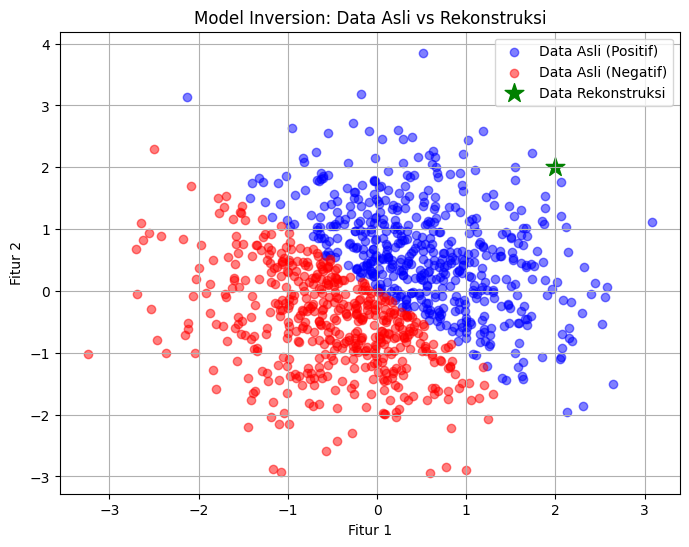

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], c='blue', label='Data Asli (Positif)', alpha=0.5)
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], c='red', label='Data Asli (Negatif)', alpha=0.5)
plt.scatter(reconstructed_data[0, 0], reconstructed_data[0, 1], c='green', marker='*', s=200, label='Data Rekonstruksi')
plt.title('Model Inversion: Data Asli vs Rekonstruksi')
plt.xlabel('Fitur 1')
plt.ylabel('Fitur 2')
plt.legend()
plt.grid(True)
plt.savefig('model_inversion_plot.png')
plt.show()